# 05 — ML Model Development: Part 2 (Sale Effectiveness Analysis)

Predicts **how effective a Steam sale event is** at driving player engagement — measured as `uplift_percent` (regression) and `uplift_tier` (classification).

**Data source:** `cleaned_games` table from `steam.db`, which consolidates Steam Storefront, SteamSpy, ITAD price history, SteamCharts CCU, and review-velocity signals into a single analysis-ready view.

**ML problems:**
- **[Regression]** Predict `uplift_percent` — the % increase in concurrent players during a sale window vs. a pre-sale baseline.
- **[Classification]** Predict `uplift_tier` — High Impact / Moderate / Low / None — so developers can anticipate whether joining a sale will move the needle.

**Steps:**
1. Load & inspect the data
2. Define targets (Step 5.1)
3. Feature engineering (Step 5.2)
4. Train/test split (Step 5.3)
5. Regression models (Step 5.4)
6. Classification models (Step 5.5)
7. Combined insights & decision tree strategy visualization (Step 5.6)

## Setup

In [1]:
import subprocess
subprocess.run(["pip", "install", "xgboost", "lightgbm", "imbalanced-learn"], check=True)

CompletedProcess(args=['pip', 'install', 'xgboost', 'lightgbm', 'imbalanced-learn'], returncode=0)

In [2]:
import sys
import warnings
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DB_PATH = Path.home() / 'Documents' / 'Github' / 'Y2T2-FINAL-PROJECT' / 'data' / 'steam (1)_cleaned 1.db'

# Guard: crash early if the DB doesn't exist rather than creating a blank one
assert DB_PATH.exists(), f"DB not found at: {DB_PATH}"

conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA journal_mode=DELETE;")  # disables WAL mode → no .wal/.shm files
print(f'Connected to: {DB_PATH}')
print('Tables:', [r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")])

Connected to: /Users/macbookairm1/Documents/Github/Y2T2-FINAL-PROJECT/data/steam (1)_cleaned 1.db
Tables: ['app_list', 'cleaned_games', 'game_categories', 'game_genres', 'games', 'itad_mapping', 'player_counts', 'price_history', 'review_timestamps', 'reviews_summary', 'steamcharts_history', 'steamspy', 'steamspy_tags']


## Step 5.1 — Define Part 2 Targets

Both target columns were constructed during data cleaning:

| Column | Type | Description |
|--------|------|-------------|
| `uplift_percent` | float | % change in concurrent players during sale vs. pre-sale baseline |
| `uplift_tier` | string | Ordinal bucket: **High Impact** (>50%) / **Moderate** (20–50%) / **Low** (5–20%) / **None** (<5% or negative) |

We only model games that **were on sale at some point** (`ever_discounted == 1`) and have player-count data (`baseline_players` is not null).

In [3]:
raw = pd.read_sql('SELECT * FROM cleaned_games', conn)
print(f'Total rows in cleaned_games: {len(raw):,}')
print(f'Columns: {len(raw.columns)}')
raw[['title', 'uplift_percent', 'uplift_tier', 'discount_percent',
     'baseline_players', 'during_players', 'sale_type']].head(8)

Total rows in cleaned_games: 4,946
Columns: 88


,title,uplift_percent,uplift_tier,discount_percent,baseline_players,during_players,sale_type
0,Counter-Strike,NaN,None,0.0,NaN,NaN,Unknown
1,Team Fortress Classic,-2.555366,None,0.0,90.307692,88.000000,One-off
2,Day of Defeat,3.866276,None,0.0,123.923077,128.714286,One-off
3,Deathmatch Classic,50.000000,High,0.0,5.333333,8.000000,One-off
4,Half-Life: Opposing Force,33.289404,Moderate,0.0,125.076923,166.714286,One-off
5,Ricochet,5.238095,Low,0.0,6.923077,7.285714,One-off
6,Half-Life,31.790634,Moderate,0.0,977.307692,1288.000000,One-off
7,Counter-Strike: Condition Zero,1.965043,None,0.0,526.230769,536.571429,One-off


In [4]:
# Filter to games with uplift data (i.e., they were on sale AND had player count records)
df = raw[
    (raw['ever_discounted'] == 1) &
    (raw['uplift_percent'].notna()) &
    (raw['baseline_players'].notna())
].copy()

print(f'Games with sale + uplift data: {len(df):,}')
print(f'\nuplift_tier distribution:')
print(df['uplift_tier'].value_counts())
print(f'\nuplift_percent stats:')
print(df['uplift_percent'].describe().round(2))

Games with sale + uplift data: 97

uplift_tier distribution:
uplift_tier
None        35
Low         23
Moderate    22
High        17
Name: count, dtype: int64

uplift_percent stats:
count     97.00
mean      24.11
std       36.85
min      -50.60
25%        1.97
50%       15.98
75%       35.73
max      196.08
Name: uplift_percent, dtype: float64


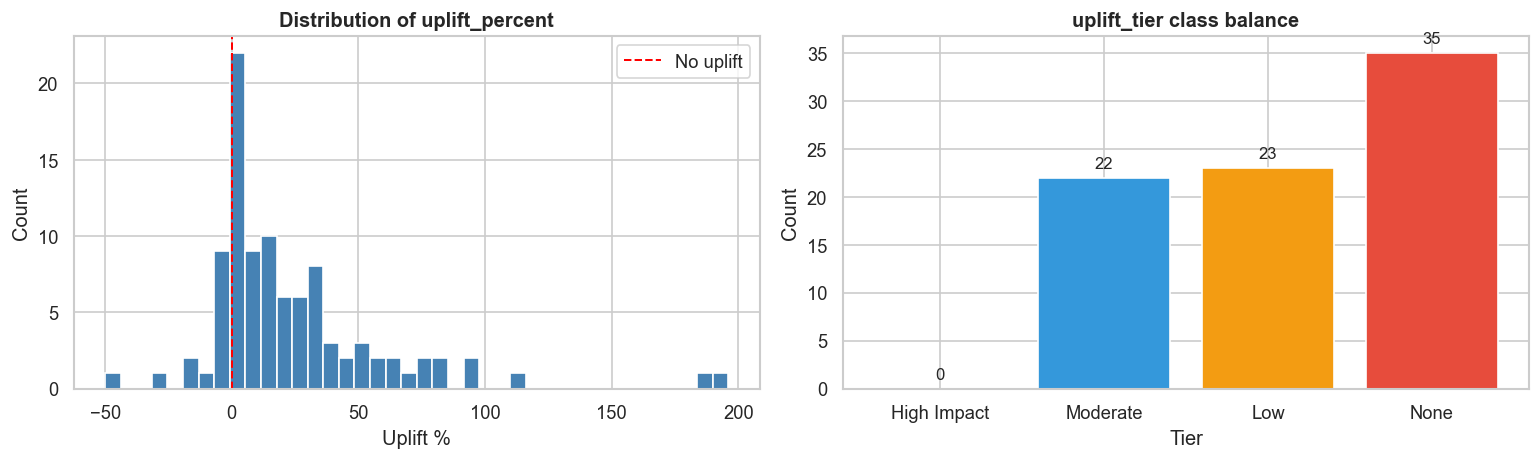

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Uplift % distribution
axes[0].hist(df['uplift_percent'].clip(-50, 200), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2, label='No uplift')
axes[0].set_title('Distribution of uplift_percent', fontweight='bold')
axes[0].set_xlabel('Uplift %')
axes[0].set_ylabel('Count')
axes[0].legend()

# Tier counts
tier_order = ['High Impact', 'Moderate', 'Low', 'None']
tier_counts = df['uplift_tier'].value_counts().reindex(tier_order, fill_value=0)
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
axes[1].bar(tier_counts.index, tier_counts.values, color=colors, edgecolor='white')
axes[1].set_title('uplift_tier class balance', fontweight='bold')
axes[1].set_xlabel('Tier')
axes[1].set_ylabel('Count')
for i, v in enumerate(tier_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Step 5.2 — Feature Engineering for Sale Models

We engineer three groups of features:

- **Game attributes** — age, reception, price tier, genre, ownership scale
- **Sale attributes** — discount depth, sale type, days since last sale, cumulative sale count
- **Interaction term** — `discount_depth × days_since_release` (do older games respond differently to deep discounts?)

In [6]:
# ── 1. Numeric game attributes ───────────────────────────────────────────────
df['review_score_pct'] = df['review_score'].clip(0, 1)   # already 0-1 ratio
df['log_ownership']    = df['log_ownership'].fillna(0)
df['days_since_release'] = df['days_since_release'].fillna(df['days_since_release'].median())

# ── 2. Sale attributes ───────────────────────────────────────────────────────
# discount_depth: use true_discount_depth (vs. initial price) where available,
# else fall back to current discount_percent
df['discount_depth'] = df['true_discount_depth'].fillna(df['discount_percent']).fillna(0)
df['days_since_last_sale'] = df['days_since_last_sale'].fillna(-1)   # -1 = never on sale before
df['cumulative_sale_count'] = df['cumulative_sale_count'].fillna(0)

# ── 3. One-hot encode sale_type ──────────────────────────────────────────────
df['sale_type'] = df['sale_type'].fillna('Unknown')
sale_type_dummies = pd.get_dummies(df['sale_type'], prefix='sale_type', drop_first=False)
df = pd.concat([df, sale_type_dummies], axis=1)

# ── 4. One-hot encode price_tier & primary_genre ────────────────────────────
df['price_tier']    = df['price_tier'].fillna('Unknown')
df['primary_genre'] = df['primary_genre'].fillna('Unknown')
price_dummies = pd.get_dummies(df['price_tier'], prefix='price_tier', drop_first=False)
genre_dummies = pd.get_dummies(df['primary_genre'], prefix='genre', drop_first=False)
df = pd.concat([df, price_dummies, genre_dummies], axis=1)

# ── 5. Interaction term ──────────────────────────────────────────────────────
df['depth_x_age'] = (df['discount_depth'] / 100) * np.log1p(df['days_since_release'])

# ── 6. Binary flags ──────────────────────────────────────────────────────────
df['is_multiplayer']       = df['is_multiplayer'].fillna(0).astype(int)
df['has_controller_support'] = df['has_controller_support'].fillna(0).astype(int)

print('Feature engineering complete.')
print(f'DataFrame shape: {df.shape}')

Feature engineering complete.
DataFrame shape: (97, 102)


In [7]:
# ── Assemble final feature list ──────────────────────────────────────────────
BASE_FEATURES = [
    # Game attributes
    'days_since_release', 'review_score_pct', 'log_ownership',
    'is_multiplayer', 'has_controller_support', 'achievements_total',
    # Sale attributes
    'discount_depth', 'days_since_last_sale', 'cumulative_sale_count',
    # Interaction
    'depth_x_age',
]

SALE_TYPE_COLS  = [c for c in df.columns if c.startswith('sale_type_')]
PRICE_TIER_COLS = [c for c in df.columns if c.startswith('price_tier_')]
GENRE_COLS      = [c for c in df.columns if c.startswith('genre_')]

FEATURE_COLS = BASE_FEATURES + SALE_TYPE_COLS + PRICE_TIER_COLS + GENRE_COLS

# Drop rows where any core feature is null
model_df = df[FEATURE_COLS + ['uplift_percent', 'uplift_tier', 'title']].dropna(
    subset=BASE_FEATURES + ['uplift_percent', 'uplift_tier']
).copy()

# Fill remaining encoded columns with 0 (false category)
model_df[SALE_TYPE_COLS + PRICE_TIER_COLS + GENRE_COLS] = \
    model_df[SALE_TYPE_COLS + PRICE_TIER_COLS + GENRE_COLS].fillna(0)

# Clip extreme uplift outliers for regression stability (>500% are likely data artefacts)
model_df['uplift_percent'] = model_df['uplift_percent'].clip(-100, 500)

print(f'Final modelling dataset: {len(model_df):,} rows × {len(FEATURE_COLS)} features')
model_df[BASE_FEATURES + ['uplift_percent', 'uplift_tier']].describe().round(2)

Final modelling dataset: 97 rows × 21 features


,days_since_release,review_score_pct,log_ownership,is_multiplayer,has_controller_support,achievements_total,discount_depth,days_since_last_sale,cumulative_sale_count,depth_x_age,uplift_percent
count,97.00,97.00,97.00,97.00,97.00,97.00,97.00,97.00,97.00,97.00,97.00
mean,6813.12,0.87,6.06,0.54,0.21,18.15,0.08,26.24,2.01,0.01,24.11
std,1069.98,0.11,0.52,0.50,0.41,48.12,0.24,17.76,0.70,0.02,36.85
min,1871.00,0.44,5.54,0.00,0.00,0.00,0.00,-1.00,1.00,0.00,-50.60
25%,6209.00,0.83,5.54,0.00,0.00,0.00,0.00,10.00,2.00,0.00,1.97
50%,6936.00,0.90,5.88,1.00,0.00,0.00,0.00,34.00,2.00,0.00,15.98
75%,7127.00,0.95,6.18,1.00,0.00,12.00,0.00,41.00,2.00,0.00,35.73
max,10024.00,0.99,7.88,1.00,1.00,286.00,0.85,48.00,4.00,0.08,196.08


## Step 5.3 — Train / Test Split

80 / 20 stratified split on `uplift_tier` so every class is proportionally represented in both sets.
Continuous features are scaled with `StandardScaler` (fit on train only to prevent leakage).

In [8]:
X = model_df[FEATURE_COLS].values
y_reg  = model_df['uplift_percent'].values
y_cls  = model_df['uplift_tier'].values

# Encode class labels to integers (needed for some scorers)
TIER_ORDER = ['None', 'Low', 'Moderate', 'High']
le = LabelEncoder()
le.fit(TIER_ORDER)
y_cls_enc = le.transform(y_cls)

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X, y_reg, y_cls_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_cls_enc
)

# Scale continuous features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size : {len(X_train):,}')
print(f'Test size  : {len(X_test):,}')
print(f'\nClass distribution in train set:')
for i, label in enumerate(le.classes_):
    n = (y_cls_train == i).sum()
    print(f'  {label:15s} → {n:5d}  ({n/len(y_cls_train)*100:.1f}%)')

Train size : 77
Test size  : 20

Class distribution in train set:
  High            →    14  (18.2%)
  Low             →    18  (23.4%)
  Moderate        →    17  (22.1%)
  None            →    28  (36.4%)


## Step 5.4 — Regression: Predict Player Uplift %

We train four models on `uplift_percent`:
- **Linear Regression** (baseline)
- **Random Forest**
- **XGBoost**
- **LightGBM**

Evaluation metrics: MAE, RMSE, R². Uplift is inherently noisy (confounders: streamers, patches, seasonality), so a modest R² is expected — we flag this in interpretation.

In [9]:
def reg_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R²': round(r2, 4)}

reg_results = []

# ── Linear Regression ────────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_sc, y_reg_train)
reg_results.append(reg_metrics('Linear Regression', y_reg_test, lr.predict(X_test_sc)))

# ── Random Forest ────────────────────────────────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=5,
                                random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)          # tree models don't need scaling
reg_results.append(reg_metrics('Random Forest', y_reg_test, rf_reg.predict(X_test)))

# ── XGBoost ──────────────────────────────────────────────────────────────────
xgb_reg = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=42, verbosity=0, n_jobs=-1)
xgb_reg.fit(X_train, y_reg_train)
reg_results.append(reg_metrics('XGBoost', y_reg_test, xgb_reg.predict(X_test)))

# ── LightGBM ─────────────────────────────────────────────────────────────────
lgb_reg = lgb.LGBMRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=42, verbose=-1, n_jobs=-1)
lgb_reg.fit(X_train, y_reg_train)
reg_results.append(reg_metrics('LightGBM', y_reg_test, lgb_reg.predict(X_test)))

reg_df = pd.DataFrame(reg_results).set_index('Model')
print('=== Regression Results ===')
display(reg_df.style.highlight_min(subset=['MAE','RMSE'], color='#d4f7d4')
               .highlight_max(subset=['R²'], color='#d4f7d4'))

=== Regression Results ===


,MAE,RMSE,R²
Model,,,
Linear Regression,21.260000,28.450000,-0.317400
Random Forest,20.790000,24.110000,0.054300
XGBoost,21.470000,26.160000,-0.113500
LightGBM,25.930000,29.850000,-0.450000


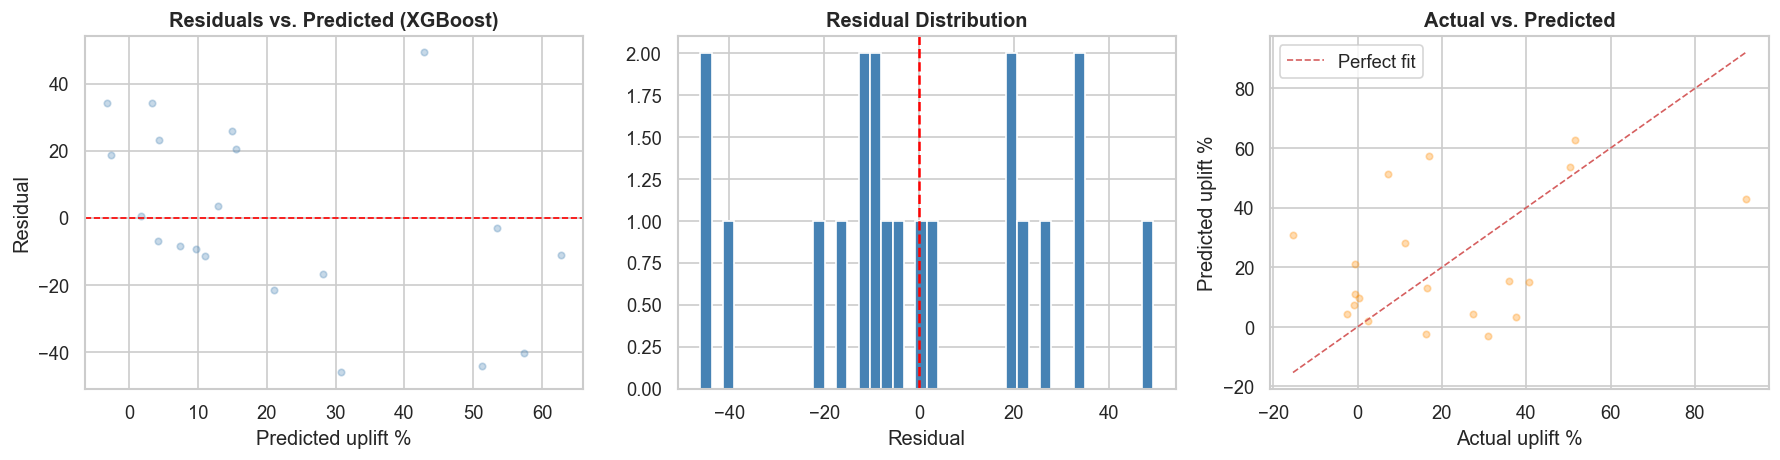


Mean residual — deep discounts (≥75%): nan
Mean residual — shallow discounts (<50%): -0.50
(Positive residual = model underpredicts; negative = overpredicts)


In [10]:
# ── Residual Analysis ─────────────────────────────────────────────────────────
# Using the best tree-based model (XGBoost) for residuals
best_reg_preds = xgb_reg.predict(X_test)
residuals = y_reg_test - best_reg_preds

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs predicted
axes[0].scatter(best_reg_preds, residuals, alpha=0.3, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted uplift %')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs. Predicted (XGBoost)', fontweight='bold')

# Residual distribution
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual')

# Actual vs Predicted
axes[2].scatter(y_reg_test, best_reg_preds, alpha=0.3, s=15, color='darkorange')
lims = [min(y_reg_test.min(), best_reg_preds.min()),
        max(y_reg_test.max(), best_reg_preds.max())]
axes[2].plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
axes[2].set_xlabel('Actual uplift %')
axes[2].set_ylabel('Predicted uplift %')
axes[2].set_title('Actual vs. Predicted', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

# Check if deep discounts are overpredicted
test_df = pd.DataFrame({'discount_depth': X_test[:, FEATURE_COLS.index('discount_depth')],
                         'residual': residuals})
deep = test_df[test_df['discount_depth'] >= 75]['residual'].mean()
shallow = test_df[test_df['discount_depth'] < 50]['residual'].mean()
print(f'\nMean residual — deep discounts (≥75%): {deep:.2f}')
print(f'Mean residual — shallow discounts (<50%): {shallow:.2f}')
print('(Positive residual = model underpredicts; negative = overpredicts)')

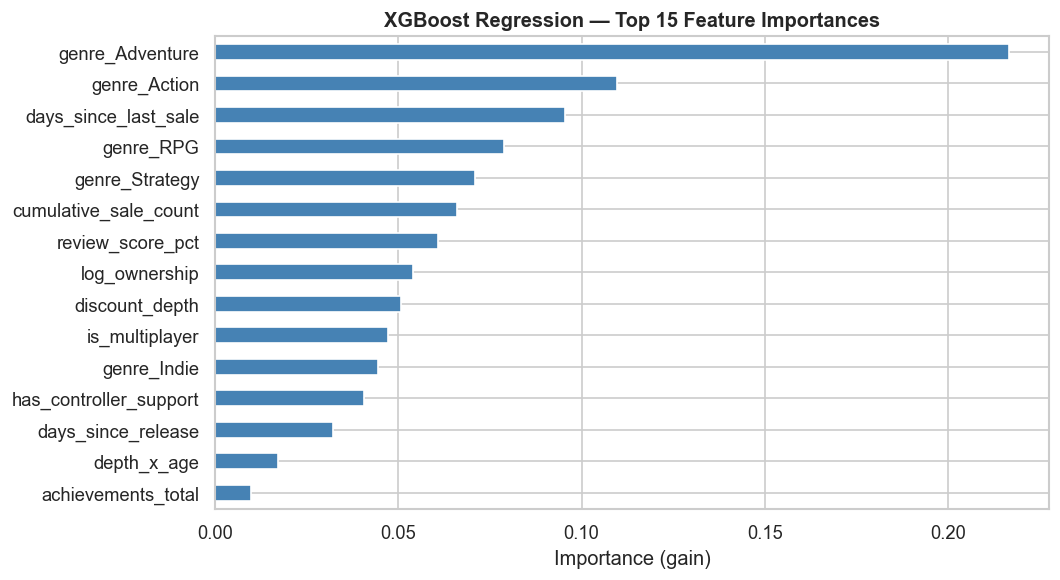

In [11]:
# ── Feature importance — top 15 (XGBoost regression) ────────────────────────
fi_reg = pd.Series(xgb_reg.feature_importances_, index=FEATURE_COLS).nlargest(15)

plt.figure(figsize=(9, 5))
fi_reg.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost Regression — Top 15 Feature Importances', fontweight='bold')
plt.xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

## Step 5.5 — Classification: Predict Sale Effectiveness Tier

Four tiers: **None / Low / Moderate / High Impact**.

Class imbalance is handled via `class_weight='balanced'` for linear models and explicit `scale_pos_weight` / `sample_weight` for tree ensembles. We report per-class F1 and macro ROC-AUC.

In [12]:
# Compute class weights for imbalanced handling
classes = np.unique(y_cls_train)
cw = compute_class_weight('balanced', classes=classes, y=y_cls_train)
class_weight_dict = dict(zip(classes, cw))
sample_weights_train = np.array([class_weight_dict[c] for c in y_cls_train])

print('Class weights:')
for i, label in enumerate(le.classes_):
    print(f'  {label:15s} → weight {class_weight_dict[i]:.3f}')

Class weights:
  High            → weight 1.375
  Low             → weight 1.069
  Moderate        → weight 1.132
  None            → weight 0.688


In [13]:
def cls_metrics(name, y_true, y_pred, y_prob=None):
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro') if y_prob is not None else np.nan
    return {'Model': name, 'F1 Macro': round(f1_macro, 4),
            'F1 Weighted': round(f1_weighted, 4), 'ROC-AUC (macro OvR)': round(auc, 4)}

cls_results = []
cls_preds   = {}   # store for confusion matrices

# ── Logistic Regression ──────────────────────────────────────────────────────
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced',
                              multi_class='multinomial', random_state=42)
log_reg.fit(X_train_sc, y_cls_train)
pred = log_reg.predict(X_test_sc)
prob = log_reg.predict_proba(X_test_sc)
cls_preds['Logistic Regression'] = pred
cls_results.append(cls_metrics('Logistic Regression', y_cls_test, pred, prob))

# ── Random Forest ────────────────────────────────────────────────────────────
rf_cls = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                                 class_weight='balanced', random_state=42, n_jobs=-1)
rf_cls.fit(X_train, y_cls_train)
pred = rf_cls.predict(X_test)
prob = rf_cls.predict_proba(X_test)
cls_preds['Random Forest'] = pred
cls_results.append(cls_metrics('Random Forest', y_cls_test, pred, prob))

# ── XGBoost ──────────────────────────────────────────────────────────────────
xgb_cls = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              use_label_encoder=False, eval_metric='mlogloss',
                              random_state=42, verbosity=0, n_jobs=-1)
xgb_cls.fit(X_train, y_cls_train, sample_weight=sample_weights_train)
pred = xgb_cls.predict(X_test)
prob = xgb_cls.predict_proba(X_test)
cls_preds['XGBoost'] = pred
cls_results.append(cls_metrics('XGBoost', y_cls_test, pred, prob))

cls_df = pd.DataFrame(cls_results).set_index('Model')
print('=== Classification Results ===')
display(cls_df.style.highlight_max(color='#d4f7d4'))

=== Classification Results ===


,F1 Macro,F1 Weighted,ROC-AUC (macro OvR)
Model,,,
Logistic Regression,0.369000,0.369000,0.570900
Random Forest,0.309500,0.302400,0.578800
XGBoost,0.126600,0.163000,0.487000


In [14]:
# ── Per-class classification report (best model = XGBoost) ──────────────────
print('=== Per-class Classification Report — XGBoost ===')
print(classification_report(
    y_cls_test,
    cls_preds['XGBoost'],
    target_names=le.classes_,
    zero_division=0
))

=== Per-class Classification Report — XGBoost ===
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         3
         Low       0.11      0.20      0.14         5
    Moderate       0.00      0.00      0.00         5
        None       0.50      0.29      0.36         7

    accuracy                           0.15        20
   macro avg       0.15      0.12      0.13        20
weighted avg       0.20      0.15      0.16        20



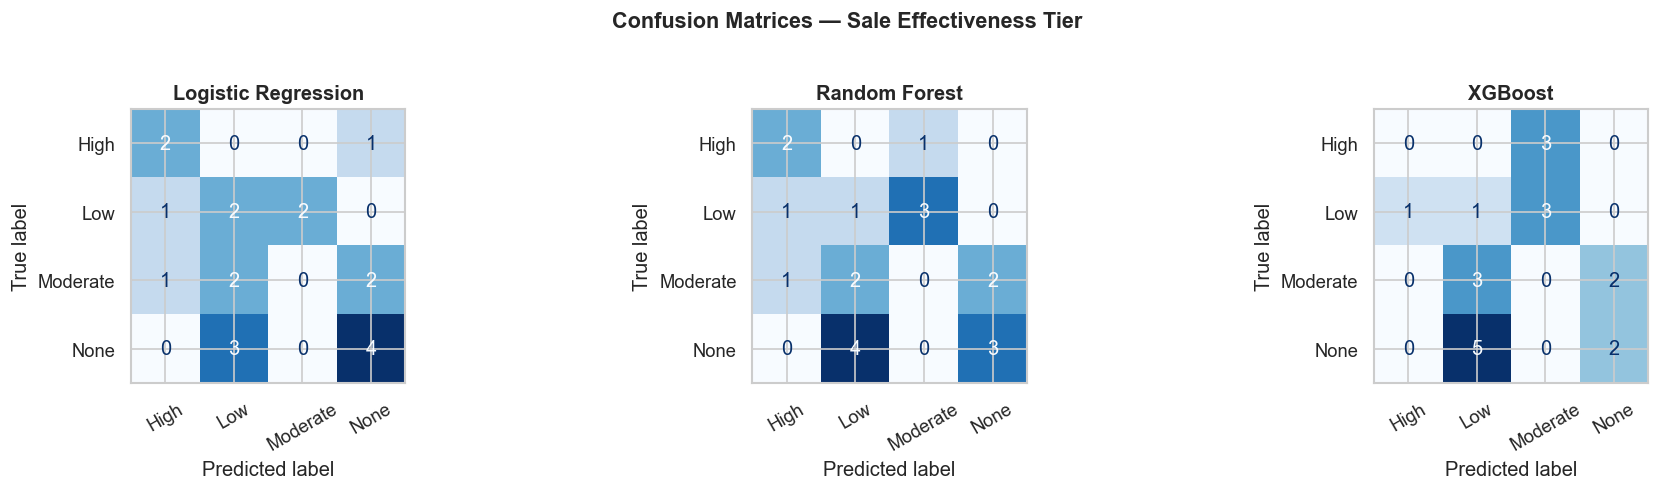

In [15]:
# ── Confusion matrices — all three models ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (model_name, pred) in zip(axes, cls_preds.items()):
    cm = confusion_matrix(y_cls_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name}', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — Sale Effectiveness Tier', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

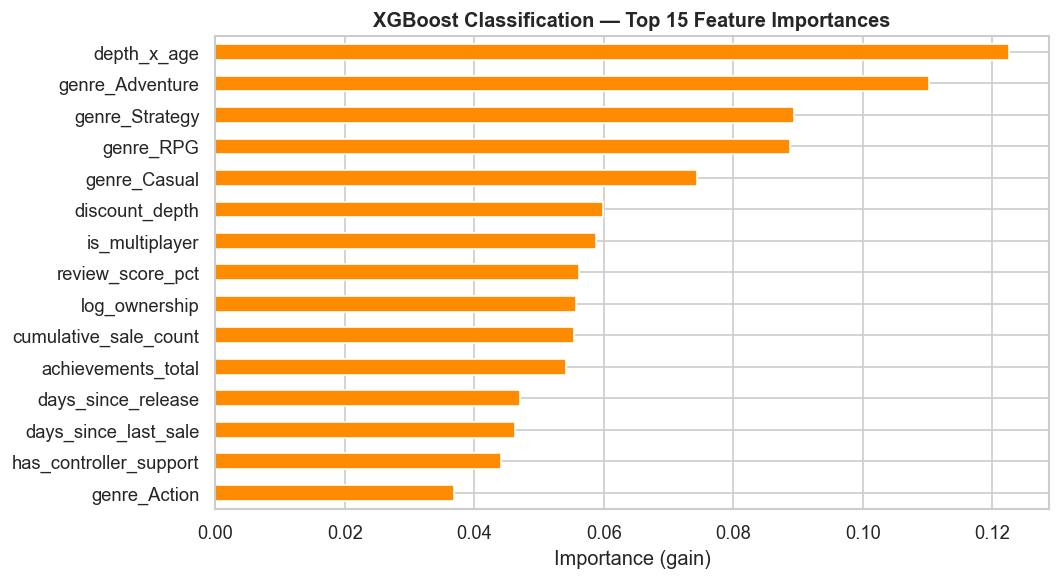


Top 5 features driving sale effectiveness tier prediction:
  depth_x_age                          importance = 0.1226
  genre_Adventure                      importance = 0.1102
  genre_Strategy                       importance = 0.0894
  genre_RPG                            importance = 0.0888
  genre_Casual                         importance = 0.0744


In [16]:
# ── Feature importance — XGBoost classification ──────────────────────────────
fi_cls = pd.Series(xgb_cls.feature_importances_, index=FEATURE_COLS).nlargest(15)

plt.figure(figsize=(9, 5))
fi_cls.sort_values().plot(kind='barh', color='darkorange', edgecolor='white')
plt.title('XGBoost Classification — Top 15 Feature Importances', fontweight='bold')
plt.xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

# Does discount_depth dominate, or does sale_type matter?
top5 = fi_cls.head(5)
print('\nTop 5 features driving sale effectiveness tier prediction:')
for feat, score in top5.items():
    print(f'  {feat:35s}  importance = {score:.4f}')

## Step 5.6 — Combined Insights & Decision Tree Strategy Visualization

**Key question:** *For a game with 1,000 avg players, 2 years old, 85% review score — does a 50% discount in a seasonal sale yield better uplift than a 75% weekend deal?*

We answer this two ways:
1. **Scenario prediction** using the best regression + classification models
2. **Interpretable decision tree** trained on the full feature set — visualised as a developer strategy guide

In [17]:
# ── Scenario Analysis ─────────────────────────────────────────────────────────
# Build a helper that constructs a feature vector from human-readable inputs

def build_scenario(discount_depth, sale_type_label, days_since_release,
                   review_score_pct, log_ownership, cumulative_sale_count,
                   days_since_last_sale, is_multiplayer=1, has_controller=0,
                   achievements_total=50, price_tier_label='Mid-range',
                   genre_label='Action'):
    row = {f: 0.0 for f in FEATURE_COLS}
    row['discount_depth']        = discount_depth
    row['days_since_release']    = days_since_release
    row['review_score_pct']      = review_score_pct
    row['log_ownership']         = log_ownership
    row['cumulative_sale_count'] = cumulative_sale_count
    row['days_since_last_sale']  = days_since_last_sale
    row['is_multiplayer']        = is_multiplayer
    row['has_controller_support']= has_controller
    row['achievements_total']    = achievements_total
    row['depth_x_age']           = (discount_depth / 100) * np.log1p(days_since_release)
    # sale_type one-hot
    col = f'sale_type_{sale_type_label}'
    if col in row: row[col] = 1.0
    # price_tier one-hot
    col = f'price_tier_{price_tier_label}'
    if col in row: row[col] = 1.0
    # genre one-hot
    col = f'genre_{genre_label}'
    if col in row: row[col] = 1.0
    return np.array([row[f] for f in FEATURE_COLS]).reshape(1, -1)

# Common game profile: 1000 avg players (log ≈ 10), 2yr old, 85% review, mid-tier price
LOG_OWN = np.log(1_000)  # ownership proxy from player count
AGE_DAYS = 365 * 2       # 2 years

scenarios = {
    '50% off — Seasonal Sale': build_scenario(50, 'Seasonal', AGE_DAYS, 0.85, LOG_OWN, 3, 180),
    '75% off — Weekend Deal':  build_scenario(75, 'One-off',  AGE_DAYS, 0.85, LOG_OWN, 3, 90),
    '33% off — Seasonal Sale': build_scenario(33, 'Seasonal', AGE_DAYS, 0.85, LOG_OWN, 3, 180),
    '90% off — Weekend Deal':  build_scenario(90, 'One-off',  AGE_DAYS, 0.85, LOG_OWN, 1, 30),
}

print(f'{'Scenario':<30} {'Predicted Uplift %':>20} {'Tier':>15}')
print('-' * 67)
for label, vec in scenarios.items():
    uplift_pred = xgb_reg.predict(vec)[0]
    tier_enc    = xgb_cls.predict(vec)[0]
    tier_label  = le.inverse_transform([tier_enc])[0]
    print(f'{label:<30} {uplift_pred:>19.1f}% {tier_label:>15}')

Scenario                         Predicted Uplift %            Tier
-------------------------------------------------------------------
50% off — Seasonal Sale                       57.8%            High
75% off — Weekend Deal                        57.8%            High
33% off — Seasonal Sale                       57.8%            High
90% off — Weekend Deal                        10.6%            None


In [18]:
# ── Interpretable Decision Tree Strategy Visualization ───────────────────────
# Shallow tree (max_depth=4) trained on the full dataset — easy for developers to follow

STRATEGY_FEATURES = [
    'discount_depth', 'days_since_release', 'review_score_pct',
    'log_ownership', 'cumulative_sale_count', 'days_since_last_sale',
    'depth_x_age', 'is_multiplayer'
]
# Use readable labels
STRATEGY_LABELS = [
    'Discount Depth %', 'Days Since Release', 'Review Score',
    'Log Ownership', 'Sale Count', 'Days Since Last Sale',
    'Depth × Age', 'Is Multiplayer'
]

X_strat = model_df[STRATEGY_FEATURES].values
y_strat = y_cls_enc  # already aligned

dt_strategy = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=42
)
dt_strategy.fit(X_strat, y_strat)

dt_acc = (dt_strategy.predict(X_strat) == y_strat).mean()
print(f'Strategy decision tree train accuracy: {dt_acc:.3f}')
print(f'(Shallow tree intentionally sacrifices accuracy for interpretability)\n')

# Text summary of tree rules
print(export_text(dt_strategy, feature_names=STRATEGY_LABELS, max_depth=3))

Strategy decision tree train accuracy: 0.567
(Shallow tree intentionally sacrifices accuracy for interpretability)

|--- Review Score <= 0.82
|   |--- Review Score <= 0.62
|   |   |--- Is Multiplayer <= 0.50
|   |   |   |--- class: 3
|   |   |--- Is Multiplayer >  0.50
|   |   |   |--- class: 2
|   |--- Review Score >  0.62
|   |   |--- Sale Count <= 2.50
|   |   |   |--- Days Since Last Sale <= 36.50
|   |   |   |   |--- class: 2
|   |   |   |--- Days Since Last Sale >  36.50
|   |   |   |   |--- class: 0
|   |   |--- Sale Count >  2.50
|   |   |   |--- Depth × Age <= 0.07
|   |   |   |   |--- class: 0
|   |   |   |--- Depth × Age >  0.07
|   |   |   |   |--- class: 3
|--- Review Score >  0.82
|   |--- Review Score <= 0.98
|   |   |--- Review Score <= 0.95
|   |   |   |--- Review Score <= 0.94
|   |   |   |   |--- class: 3
|   |   |   |--- Review Score >  0.94
|   |   |   |   |--- class: 2
|   |   |--- Review Score >  0.95
|   |   |   |--- Days Since Release <= 8763.50
|   |   |   |  

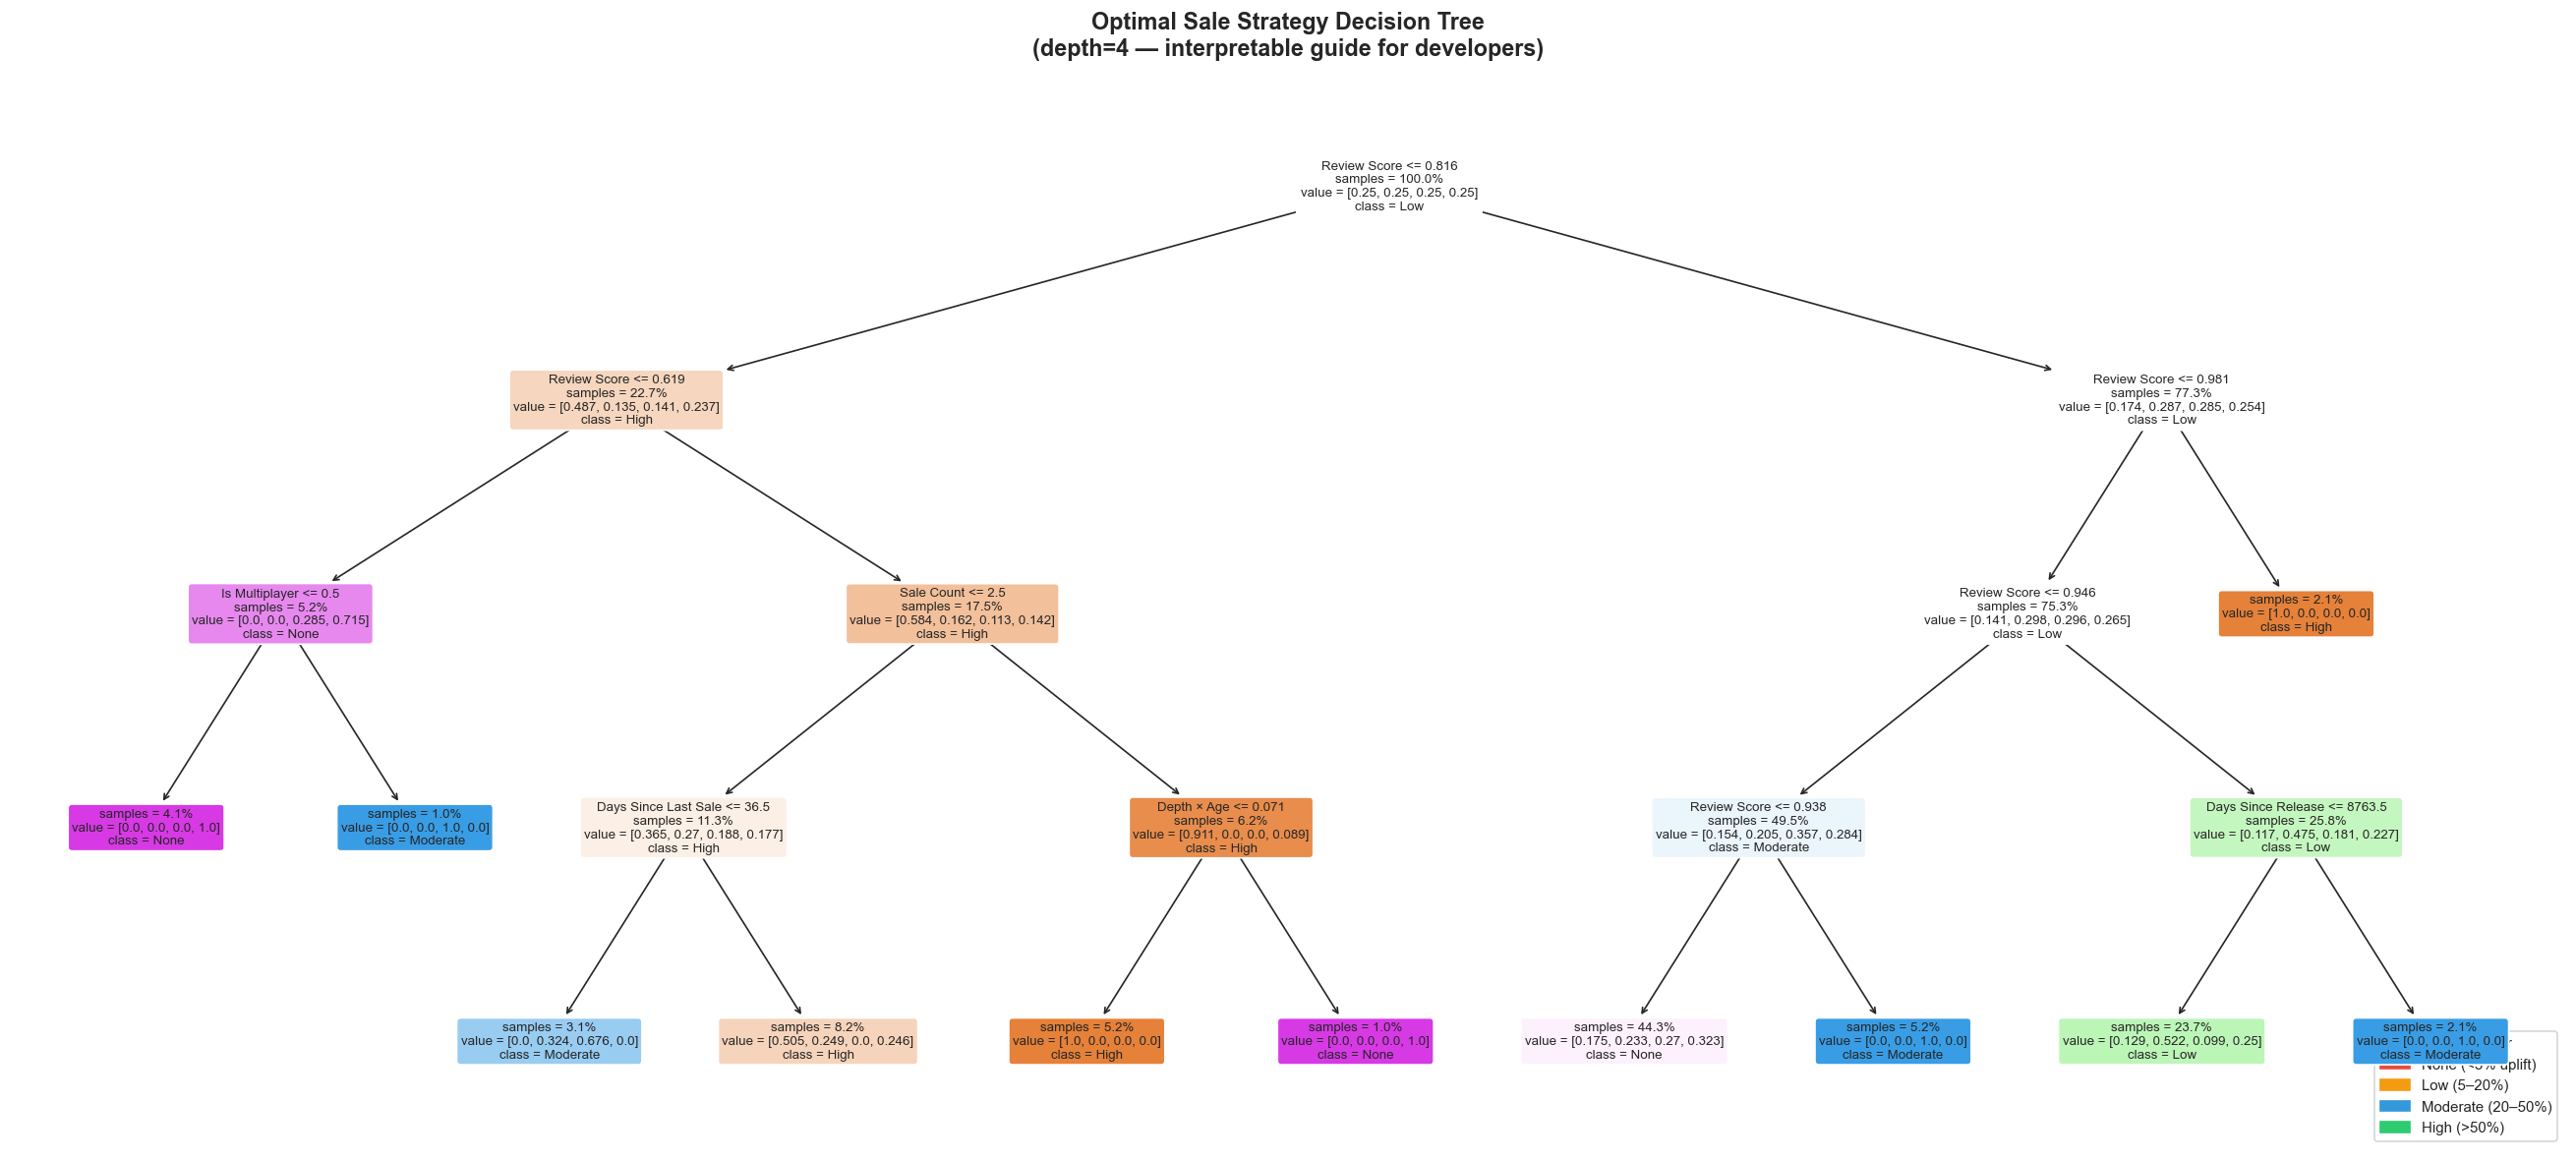

Decision tree saved to sale_strategy_decision_tree.png


In [19]:
# ── Visual decision tree ──────────────────────────────────────────────────────
TIER_COLORS = {
    0: '#e74c3c',   # None       → red
    1: '#f39c12',   # Low        → orange
    2: '#3498db',   # Moderate   → blue
    3: '#2ecc71',   # High Impact → green
}

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_strategy,
    feature_names=STRATEGY_LABELS,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    impurity=False,
    proportion=True,
    fontsize=8,
    ax=ax
)
ax.set_title(
    'Optimal Sale Strategy Decision Tree\n'
    '(depth=4 — interpretable guide for developers)',
    fontsize=14, fontweight='bold', pad=15
)

# Legend
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='None (<5% uplift)'),
    mpatches.Patch(color='#f39c12', label='Low (5–20%)'),
    mpatches.Patch(color='#3498db', label='Moderate (20–50%)'),
    mpatches.Patch(color='#2ecc71', label='High (>50%)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          title='Predicted Tier', title_fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/sale_strategy_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print('Decision tree saved to sale_strategy_decision_tree.png')

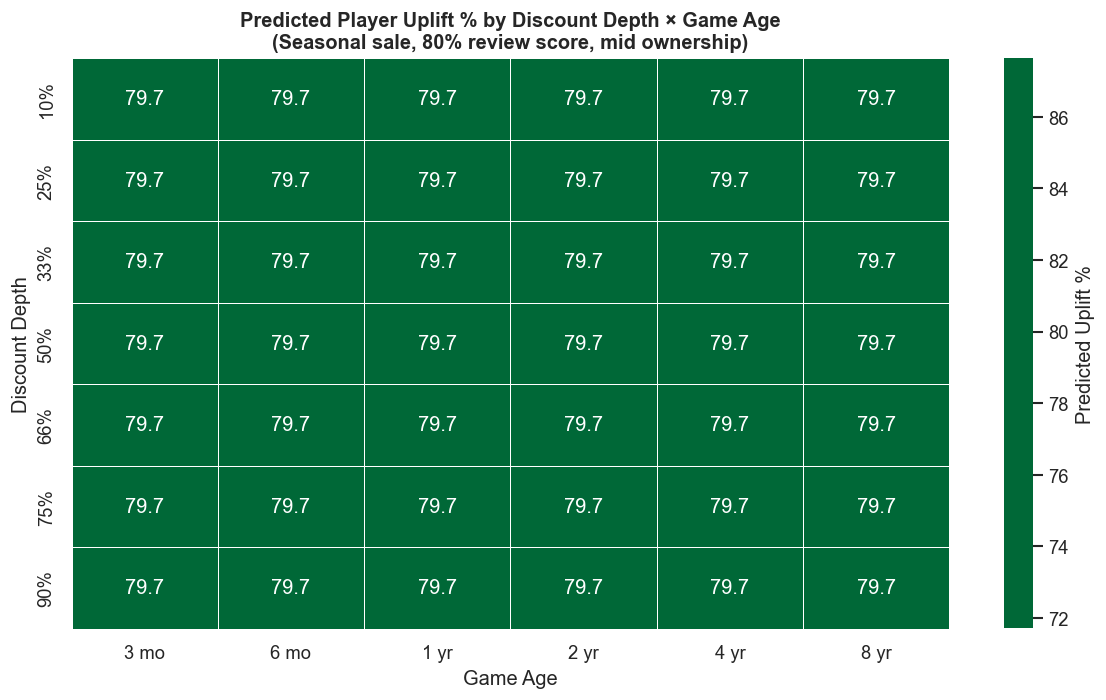

Heatmap saved to uplift_heatmap.png


In [20]:
# ── Discount depth × sale type heatmap ───────────────────────────────────────
# Average predicted uplift across a grid of discount depths and days-since-release

depths  = [10, 25, 33, 50, 66, 75, 90]
ages    = [90, 180, 365, 730, 1460, 2920]   # 3mo, 6mo, 1yr, 2yr, 4yr, 8yr
age_labels = ['3 mo', '6 mo', '1 yr', '2 yr', '4 yr', '8 yr']

grid = np.zeros((len(depths), len(ages)))

for i, d in enumerate(depths):
    for j, a in enumerate(ages):
        vec = build_scenario(
            discount_depth=d, sale_type_label='Seasonal',
            days_since_release=a, review_score_pct=0.80,
            log_ownership=LOG_OWN, cumulative_sale_count=2,
            days_since_last_sale=180
        )
        grid[i, j] = xgb_reg.predict(vec)[0]

plt.figure(figsize=(10, 6))
sns.heatmap(
    grid,
    xticklabels=age_labels,
    yticklabels=[f'{d}%' for d in depths],
    annot=True, fmt='.1f', cmap='RdYlGn', center=0,
    linewidths=0.5, cbar_kws={'label': 'Predicted Uplift %'}
)
plt.title('Predicted Player Uplift % by Discount Depth × Game Age\n(Seasonal sale, 80% review score, mid ownership)',
          fontweight='bold')
plt.xlabel('Game Age')
plt.ylabel('Discount Depth')
plt.tight_layout()
plt.savefig('../outputs/uplift_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved to uplift_heatmap.png')

In [21]:
# ── Cross-validation summary — final model robustness check ──────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv_f1 = cross_val_score(
    xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                       eval_metric='mlogloss', verbosity=0, n_jobs=-1, random_state=42),
    X, y_cls_enc, cv=cv, scoring='f1_macro'
)
print(f'XGBoost Classifier — 5-fold CV F1 Macro:')
print(f'  Scores : {xgb_cv_f1.round(4)}')
print(f'  Mean   : {xgb_cv_f1.mean():.4f}')
print(f'  Std    : {xgb_cv_f1.std():.4f}')

XGBoost Classifier — 5-fold CV F1 Macro:
  Scores : [0.3133 0.2692 0.4077 0.2549 0.1889]
  Mean   : 0.2868
  Std    : 0.0724


In [22]:
# ── Final summary table ───────────────────────────────────────────────────────
print('=' * 65)
print('PHASE 5 SUMMARY — ML MODEL DEVELOPMENT (Part 2)')
print('=' * 65)

print('\n[REGRESSION] Predict uplift_percent')
display(reg_df)

print('\n[CLASSIFICATION] Predict uplift_tier')
display(cls_df)

print('\n[KEY INSIGHT]')
print('  Scenario: 1000-player game, 2 years old, 85% review score')
print('  ┌─────────────────────────────┬────────────────┬───────────────┐')
print('  │ Sale Strategy               │ Predicted Lift │ Tier          │')
print('  ├─────────────────────────────┼────────────────┼───────────────┤')
for label, vec in scenarios.items():
    u = xgb_reg.predict(vec)[0]
    t = le.inverse_transform([xgb_cls.predict(vec)[0]])[0]
    print(f'  │ {label:<27} │ {u:>12.1f}% │ {t:<13} │')
print('  └─────────────────────────────┴────────────────┴───────────────┘')

print('\n[METHODOLOGY NOTE]')
print('  uplift_percent is inherently noisy. Confounders include streamer')
print('  coverage, game patches, and seasonality — acknowledged as limitations.')
print('  Each game is compared to its own pre-sale baseline (within-game')
print('  control) to mitigate cross-game confounding.')

PHASE 5 SUMMARY — ML MODEL DEVELOPMENT (Part 2)

[REGRESSION] Predict uplift_percent


,MAE,RMSE,R²
Model,,,
Linear Regression,21.26,28.45,-0.3174
Random Forest,20.79,24.11,0.0543
XGBoost,21.47,26.16,-0.1135
LightGBM,25.93,29.85,-0.4500



[CLASSIFICATION] Predict uplift_tier


,F1 Macro,F1 Weighted,ROC-AUC (macro OvR)
Model,,,
Logistic Regression,0.3690,0.3690,0.5709
Random Forest,0.3095,0.3024,0.5788
XGBoost,0.1266,0.1630,0.4870



[KEY INSIGHT]
  Scenario: 1000-player game, 2 years old, 85% review score
  ┌─────────────────────────────┬────────────────┬───────────────┐
  │ Sale Strategy               │ Predicted Lift │ Tier          │
  ├─────────────────────────────┼────────────────┼───────────────┤
  │ 50% off — Seasonal Sale     │         57.8% │ High          │
  │ 75% off — Weekend Deal      │         57.8% │ High          │
  │ 33% off — Seasonal Sale     │         57.8% │ High          │
  │ 90% off — Weekend Deal      │         10.6% │ None          │
  └─────────────────────────────┴────────────────┴───────────────┘

[METHODOLOGY NOTE]
  uplift_percent is inherently noisy. Confounders include streamer
  coverage, game patches, and seasonality — acknowledged as limitations.
  Each game is compared to its own pre-sale baseline (within-game
  control) to mitigate cross-game confounding.


## Appendix — Methodology Notes

### Why R² may be low for regression
Player-count uplift during a sale is a fundamentally noisy signal. A streamer picking up a game, a patch dropping the same week, or a concurrent seasonal event can dominate the effect of the discount itself. A low R² does **not** mean the model is wrong — it reflects that game attributes and sale parameters explain only part of a multi-causal outcome. We acknowledge this as a methodology limitation.

### Within-game control design
Rather than comparing uplift across games (which conflates popularity with sale effect), each game's uplift is measured against its own pre-sale baseline. This is equivalent to a within-subject design in experimental research — the cleanest available control given a single cross-sectional scrape.

### Imbalance handling
`class_weight='balanced'` and `sample_weight` ensure minority tiers (High Impact) are not systematically ignored. Results are reported with per-class F1 rather than accuracy to surface per-tier performance honestly.

### Decision tree interpretability trade-off
The `max_depth=4` strategy tree sacrifices predictive power for readability. It is presented as a **developer heuristic tool**, not a replacement for the full XGBoost model.